In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [2]:
InsuranceData = pd.read_csv('insurance.csv')
InsuranceData.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
dup = InsuranceData.duplicated().sum()
print("Number of duplicated records: ",dup )
InsuranceData = InsuranceData.drop_duplicates(keep = "first", inplace=False)

Number of duplicated records:  1


In [4]:
InsuranceData["smoker_yes"] = (InsuranceData["smoker"] == "yes").astype(int)
InsuranceData["bmi_smoker"] = InsuranceData["bmi"] * InsuranceData["smoker_yes"]
InsuranceData["age_smoker"] = InsuranceData["age"] * InsuranceData["smoker_yes"]
InsuranceData["bmi_age"] = InsuranceData["bmi"] * InsuranceData["age"]
InsuranceData["no_children"] = InsuranceData["children"] + 1

In [5]:
inp = InsuranceData.drop(columns=["charges"])
out = InsuranceData["charges"]

In [6]:
inpTrain, inpTest, outTrain, outTest = train_test_split(inp, out, test_size=0.2, random_state=42 , stratify=inp["smoker"])

In [7]:
preprocessor = ColumnTransformer(transformers = [
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    selector(dtype_include = ["object" , "category"])),
    (
        "num", "passthrough",
        selector(dtype_include = ["int64" , "float64"])),
])
inpTrainProcessed = preprocessor.fit_transform(inpTrain)
inpTestProcessed = preprocessor.transform(inpTest)  

In [8]:
class GradientBoostingRegressor:

    def __init__(self, NumTrees=100, LearningRate=0.1, max_depth=3):
        self.NumTrees = NumTrees
        self.LearningRate = LearningRate
        self.max_depth = max_depth
        self.trees = []
        self.InitPredic = None

    def fit(self, X, y):
        self.InitValue = y.mean()
        yPredict = np.full(len(y), self.InitValue)
        for _ in range(self.NumTrees):
            Residuals = y - yPredict
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=3,
                random_state=42,
            )
            tree.fit(X, Residuals)
            yPredict += self.LearningRate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X):
        yPredict = np.full(X.shape[0], self.InitValue)
        for tree in self.trees:
            yPredict += self.LearningRate * tree.predict(X)
        return yPredict

In [9]:
gbmodel = GradientBoostingRegressor(
    NumTrees=100,
    LearningRate=0.06,
    max_depth=2
    )
gbmodel.fit(inpTrainProcessed, outTrain.values)

In [10]:
# predict on the test set (shapes must match outTest)
yPredict = gbmodel.predict(inpTestProcessed)

R2 = r2_score(outTest, yPredict)
MAE = mean_absolute_error(outTest, yPredict)
MSE = mean_squared_error(outTest, yPredict)
RMSE = np.sqrt(MSE)

print(f"R2: {R2:.4f}")
print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

R2: 0.9205
MAE: 2106.6097
MSE: 11459863.3957
RMSE: 3385.2420


Text(0.5, 0, 'Actual')

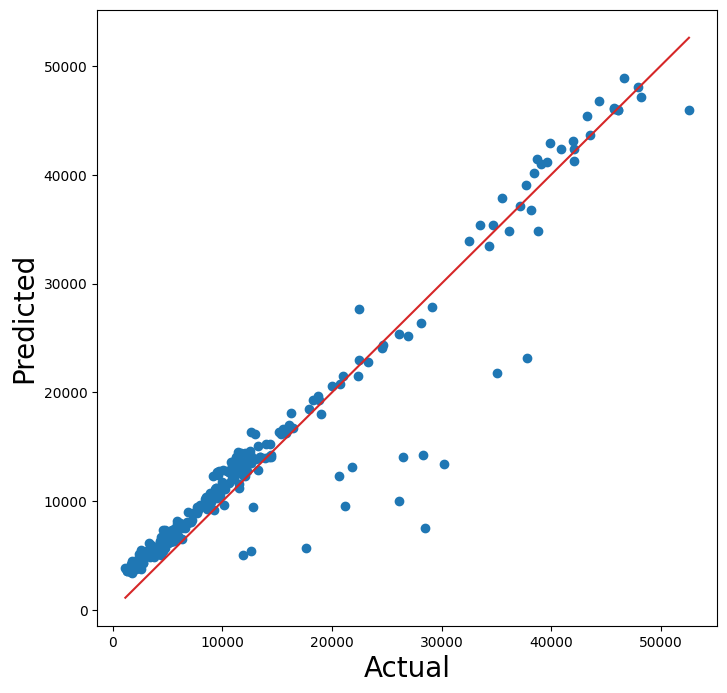

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,8))

plt.scatter(outTest,yPredict)
ax.plot([outTest.min(), outTest.max()], [outTest.min(), outTest.max()], color='tab:red')

plt.ylabel('Predicted',size=20)
plt.xlabel('Actual',size=20)

In [12]:
baseLine = gbmodel.predict(inpTestProcessed)
baseLineR2 = r2_score(outTest, baseLine)


Average Permutation Importances:
region: -0.0007
sex: 0.0000
children: 0.0041
age: 0.2021
bmi: 0.2615
smoker: 1.3414


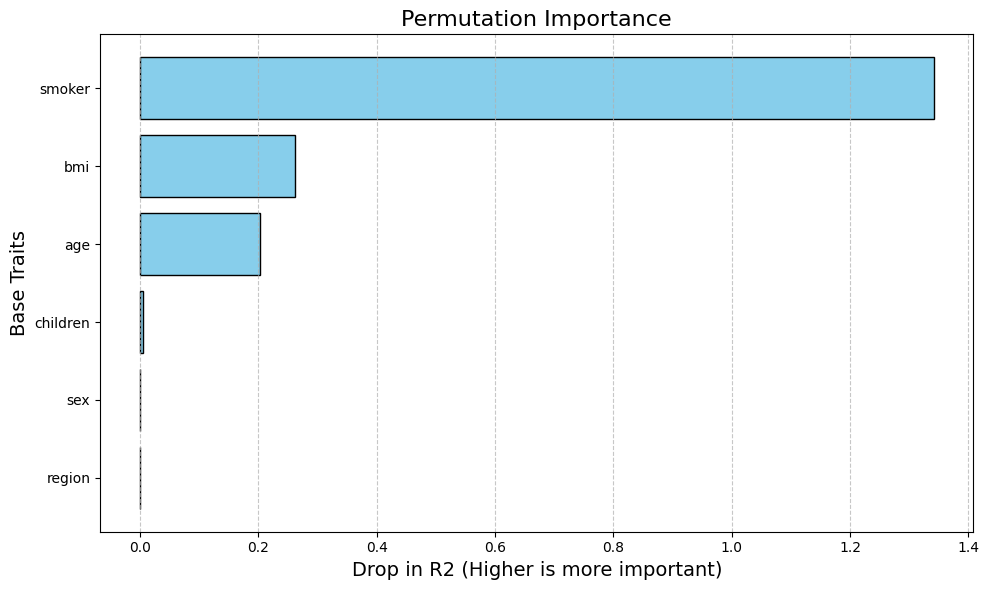

In [13]:
importances = {}
baseColumns = ["age", "bmi", "children", "sex", "smoker", "region"]
repeat = 5
for col in baseColumns:
    featureScore = []
    for i in range(repeat):
        inpTestPermuted = inpTest.copy()
        inpTestPermuted[col] = np.random.permutation(inpTestPermuted[col])
        if col == "smoker":
            inpTestPermuted["smoker_yes"] = (inpTestPermuted["smoker"] == "yes").astype(int)
            inpTestPermuted["bmi_smoker"] = inpTestPermuted["bmi"] * inpTestPermuted["smoker_yes"]
            inpTestPermuted["age_smoker"] = inpTestPermuted["age"] * inpTestPermuted["smoker_yes"]
        elif col == "bmi":
            inpTestPermuted["bmi_smoker"] = inpTestPermuted["bmi"] * inpTestPermuted["smoker_yes"]
            inpTestPermuted["bmi_age"] = inpTestPermuted["bmi"] * inpTestPermuted["age"]
        elif col == "age":
            inpTestPermuted["age_smoker"] = inpTestPermuted["age"] * inpTestPermuted["smoker_yes"]
            inpTestPermuted["bmi_age"] = inpTestPermuted["bmi"] * inpTestPermuted["age"]
        elif col == "children":
            inpTestPermuted["no_children"] = inpTestPermuted["children"] + 1
    
        permutedTestProcessed = preprocessor.transform(inpTestPermuted)
        permutedPridict = gbmodel.predict(permutedTestProcessed)
        PermutedR2 = r2_score(outTest, permutedPridict)
        featureScore.append(baseLineR2 - PermutedR2)
    importances[col] = np.mean(featureScore)

print("Average Permutation Importances:")
featureImportanceList = sorted(importances.items(), key=lambda x: x[1], reverse=False)
for feature, imp in featureImportanceList:
    print(f"{feature}: {imp:.4f}")

features = [item[0] for item in featureImportanceList]
scores = [item[1] for item in featureImportanceList]
figure , ax = plt.subplots(figsize=(10, 6))
ax.barh(features, scores, color='skyblue' , edgecolor='black')
ax.set_xlabel('Drop in R2 (Higher is more important)', size=14)
ax.set_ylabel('Base Traits', size=14)
ax.set_title('Permutation Importance', size=16)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Average Permutation Importances of Engineered Features:
no_children: 0.0004
smoker_yes: 0.0110
bmi_age: 0.0254
age_smoker: 0.0293
bmi_smoker: 0.8655


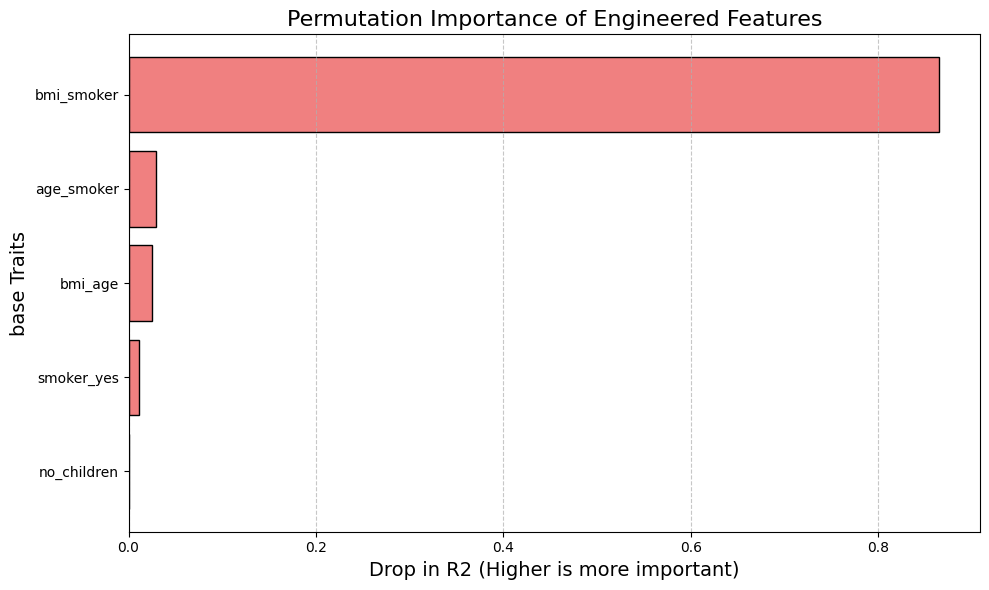

In [14]:
EngineeredFeaturesImportance = {}
Efeatures = ["smoker_yes", "bmi_smoker", "age_smoker", "bmi_age", "no_children"]
Erepeat = 5
for col in Efeatures:
    EfeaturesScore = []
    for i in range(Erepeat):
        inpTestPermuted = inpTest.copy()
        inpTestPermuted[col] = np.random.permutation(inpTestPermuted[col])
        permutedTestProcessed = preprocessor.transform(inpTestPermuted)
        permutedPridict = gbmodel.predict(permutedTestProcessed)
        PermutedR2 = r2_score(outTest, permutedPridict)
        EfeaturesScore.append(baseLineR2 - PermutedR2)
    EngineeredFeaturesImportance[col] = np.mean(EfeaturesScore)
print("Average Permutation Importances of Engineered Features:")
EfeaturesImportanceList = sorted(EngineeredFeaturesImportance.items(), key=lambda x: x[1], reverse=False)
for feature, imp in EfeaturesImportanceList:
    print(f"{feature}: {imp:.4f}")

Efeatures = [item[0] for item in EfeaturesImportanceList]
Escores = [item[1] for item in EfeaturesImportanceList]
figure , ax = plt.subplots(figsize=(10, 6))
ax.barh(Efeatures, Escores, color='lightcoral' , edgecolor='black')
ax.set_xlabel('Drop in R2 (Higher is more important)', size=14)
ax.set_ylabel('base Traits', size=14)
ax.set_title('Permutation Importance of Engineered Features', size=16)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# Save the model and preprocessor using joblib
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(gbmodel, 'model/insurance_gbmodel.pkl')
joblib.dump(preprocessor, 'model/insurance_preprocessor.pkl')

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
